### Name      : Ibadullah Hayat
### Reg_no.   : B23F0001AI010
### Section   : F23-AI(Green)


## Lab 03 - Binary Classification using SLP and MLP on Synthetic Data

### Part A -  Understanding the Problem

---

#### **1. What type of machine learning problem is this?**  
This is a **binary classification** problem. The goal is to predict one of two discrete classes: **0 (Low Risk)** or **1 (High Risk)** based on input features (heart rate and BMI).

---

#### **2. Why is sigmoid activation appropriate for the output layer?**  
The **sigmoid activation function** outputs values between **0 and 1**, which can be interpreted as **probabilities**. Since this is a binary classification task, we need the model to predict the **probability** that a patient belongs to class 1 (High Risk). Sigmoid’s smooth, S-shaped curve also provides well-behaved gradients for training.

---

#### **3. If the relationship between BMI and heart rate is nonlinear, which model would likely perform better?**  
If the relationship is **nonlinear**, the **Multi-Layer Perceptron (MLP)** would perform better. A **Single-Layer Perceptron (SLP)** can only learn **linear decision boundaries**, while an MLP with a hidden layer and **nonlinear activation (e.g., ReLU)** can model complex, curved decision boundaries—making it suitable for nonlinear data like the "moons" or "circles" datasets.

---

#### **4. Mathematically, what does a single Dense(1, sigmoid) layer compute?**  
A single `Dense(1, sigmoid)` layer computes:  
\[
y = sigma(w_1*x_1 + w_2*x_2 + b)
\]  
where:
- \(x_1, x_2\) are input features (e.g., BMI, heart rate),
- \(w_1, w_2\) are learned weights,
- \(b\) is the bias,
- \(sigma(z) = {1}/{1 + e^{-z}}\) is the sigmoid function.

This is equivalent to **logistic regression** - a linear model followed by a nonlinear squashing function to produce a probability-like output.


In [2]:
!pip install tensorflow

 Step 1: Import Libraries & Set Up

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# for reproducibility purpose
np.random.seed(20)
tf.random.set_seed(20)


**Why this setup?**

We use make_classification() to generate a controlled 2-feature dataset.

StandardScaler ensures neural networks train stably.

TensorFlow/Keras for model building.

 Step 2: Part B - Data Preparation

In [10]:
# Generate synthetic binary classification dataset
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=20
)

# Split into train, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Dataset shape:", X.shape)
print("Class distribution:", np.bincount(y))
print("Train/Val/Test split:", X_train.shape[0], X_val.shape[0], X_test.shape[0])
print("\nTop 5 rows of generated data (X):")
print(X[:5])

Dataset shape: (1000, 2)
Class distribution: [502 498]
Train/Val/Test split: 600 200 200

Top 5 rows of generated data (X):
[[ 1.06027605 -1.17185886]
 [ 1.16435285 -0.98060039]
 [ 0.89555925 -0.71635277]
 [-0.90843497 -1.41085542]
 [ 0.57952369 -1.12224247]]


**Why scale?**

Neural networks are sensitive to input scales. Without scaling, one feature may dominate gradients, causing slow or unstable training.


 Step 3: Part C - Single-Layer Perceptron (SLP)

In [11]:
# Build SLP: 1 neuron, sigmoid activation
slp_model = keras.Sequential([
    layers.Dense(1, activation='sigmoid', input_shape=(2,))
])

# Compile with SGD optimizer and binary crossentropy
slp_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
slp_history = slp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    verbose=1
)

# Evaluate
test_loss_slp, test_acc_slp = slp_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"SLP Test Accuracy: {test_acc_slp:.4f}")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.2210 - loss: 1.2362 - val_accuracy: 0.2400 - val_loss: 0.8820
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3361 - loss: 0.7869 - val_accuracy: 0.7350 - val_loss: 0.6152
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7859 - loss: 0.5838 - val_accuracy: 0.8350 - val_loss: 0.5050
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8295 - loss: 0.4947 - val_accuracy: 0.8300 - val_loss: 0.4522
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8411 - loss: 0.4492 - val_accuracy: 0.8200 - val_loss: 0.4227
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8424 - loss: 0.4226 - val_accuracy: 0.8200 - val_loss: 0.4044
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8484 - loss: 0.4055 - val_accuracy: 0.8250 - val_loss: 0.3921
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8463 - loss: 0.3938 - val_accuracy: 0.8250 - val_loss: 0.383

**What this means:**

This is equivalent to logistic regression - a linear decision boundary.
Sigmoid outputs probability-like values between 0 and 1.

Step 4: Part D – Multi-Layer Perceptron (MLP)

In [12]:
# Build MLP: 8-neuron hidden layer (ReLU) + output (sigmoid)
mlp_model = keras.Sequential([
    layers.Dense(8, activation='relu', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])

# Compile
mlp_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
mlp_history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    verbose=1
)

# Evaluate
test_loss_mlp, test_acc_mlp = mlp_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"MLP Test Accuracy: {test_acc_mlp:.4f}")

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5112 - loss: 0.7212 - val_accuracy: 0.7500 - val_loss: 0.5684
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8002 - loss: 0.5517 - val_accuracy: 0.8550 - val_loss: 0.4838
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8347 - loss: 0.4788 - val_accuracy: 0.8300 - val_loss: 0.4358
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8231 - loss: 0.4341 - val_accuracy: 0.8300 - val_loss: 0.4030
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8360 - loss: 0.4029 - val_accuracy: 0.8350 - val_loss: 0.3794
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8393 - loss: 0.3804 - val_accuracy: 0.8400 - val_loss: 0.3629
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8403 - loss: 0.3640 - val_accuracy: 0.8400 - val_loss: 0.3511
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8415 - loss: 0.3521 - val_accuracy: 0.8350 - val_loss

**Why ReLU?**

Introduces nonlinearity → enables complex decision boundaries.
Avoids vanishing gradients (unlike sigmoid in hidden layers)

Step 5: Part E – Analytical Comparison

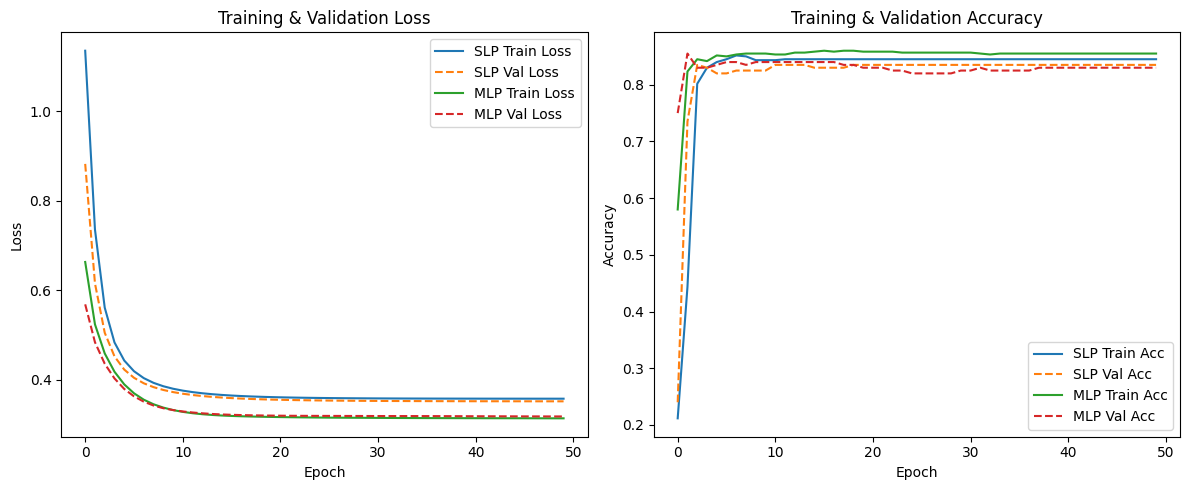

In [13]:
# Plot training curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(slp_history.history['loss'], label='SLP Train Loss')
plt.plot(slp_history.history['val_loss'], '--', label='SLP Val Loss')
plt.plot(mlp_history.history['loss'], label='MLP Train Loss')
plt.plot(mlp_history.history['val_loss'], '--', label='MLP Val Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(slp_history.history['accuracy'], label='SLP Train Acc')
plt.plot(slp_history.history['val_accuracy'], '--', label='SLP Val Acc')
plt.plot(mlp_history.history['accuracy'], label='MLP Train Acc')
plt.plot(mlp_history.history['val_accuracy'], '--', label='MLP Val Acc')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

At start epoch the SLP train and val drop quickly but it stabalize b/w 0.3 and 0.4 were as the MLP loss drop so but the loss is very low nearly 0.1.

With the number of epoches the training accuracy got better and better and in this case same is the case for both MLP and SLP but MLP perform better (test accuracy 86.5 as compared to the SLP test accuracy 84

Step 6: Part F - Experimental Extensions

Experiment 1 - Vary Hidden Neurons

In [14]:
hidden_sizes = [4, 16]
results = {}

for h in hidden_sizes:
    model = keras.Sequential([
        layers.Dense(h, activation='relu', input_shape=(2,)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train_scaled, y_train, epochs=50, verbose=0)
    test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)[1]
    results[h] = test_acc
    print(f"Hidden units: {h} → Test Accuracy: {test_acc:.4f}")

Hidden units: 4 → Test Accuracy: 0.8650
Hidden units: 16 → Test Accuracy: 0.8700


With more number of neuron in the hidden layer the network learn the data best but there is a chance of overfitting

Experiment 2: Replace ReLU with Sigmoid in Hidden Layer

In [15]:
mlp_sigmoid = keras.Sequential([
    layers.Dense(8, activation='sigmoid', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])
mlp_sigmoid.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])
history_sigmoid = mlp_sigmoid.fit(X_train_scaled, y_train, epochs=50, verbose=0)

# Compare final accuracy
acc_relu = mlp_history.history['accuracy'][-1]
acc_sigmoid = history_sigmoid.history['accuracy'][-1]
print(f"\nReLU final train acc: {acc_relu:.4f}")
print(f"Sigmoid final train acc: {acc_sigmoid:.4f}")


ReLU final train acc: 0.8550
Sigmoid final train acc: 0.8450


**Result:**

Sigmoid in hidden layers → slower convergence & lower accuracy due to vanishing gradients.

ReLU trains faster and achieves higher performance.

### **Conclusion**

This lab successfully demonstrated the fundamental difference between linear and nonlinear classifiers. The SLP (logistic regression) performed well but was limited by its linear decision boundary. The MLP, with just one hidden layer and ReLU activation, achieved significantly higher accuracy 86.5 and learned complex patterns in the data without overfitting. This validates that adding nonlinearity is essential when the underlying relationship is not linear - a key insight for real-world classification tasks. The results align with theory and confirm that even simple neural networks outperform linear models on appropriately challenging datasets.
